In [ ]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.6/112.6 GB disk)


In [ ]:
custom_yaml = """
names:
- BIODEGRADABLE
- CARDBOARD
- GLASS
- METAL
- PAPER
- PLASTIC
nc: 6
roboflow:
  license: CC BY 4.0
  project: garbage-classification-3
  url: https://universe.roboflow.com/material-identification/garbage-classification-3/dataset/1
  version: 1
  workspace: material-identification
test: /kaggle/input/garbage-0623/kaggle/working/test_cleaned
train: /kaggle/input/garbage-0623/kaggle/working/train_cleaned
val: /kaggle/input/garbage-0623/kaggle/working/valid_cleaned
"""

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Cập nhật mô hình với Dropout layers để giảm Overfitting
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Tắt ngẫu nhiên 25% kết nối
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Tắt ngẫu nhiên 50% kết nối ở lớp Dense
    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Thêm Data Augmentation cho tập train để giảm Overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/datasets/garbage_classification/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    '/content/datasets/garbage_classification/valid',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 18646 images belonging to 6 classes.
Found 2113 images belonging to 6 classes.


In [ ]:
!mkdir -p /content/datasets/garbage_classification
!unzip -q /content/archive.zip -d /content/datasets/garbage_classification
# Kiểm tra danh sách thư mục sau khi giải nén
!ls /content/datasets/garbage_classification

replace /content/datasets/garbage_classification/README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
583/583 ━━━━━━━━━━━━━━━━━━━━ 249s 421ms/step - accuracy: 0.4355 - loss: 1.4443 - val_accuracy: 0.4818 - val_loss: 1.4885 - learning_rate: 0.0010
Epoch 2/15
583/583 ━━━━━━━━━━━━━━━━━━━━ 236s 405ms/step - accuracy: 0.5118 - loss: 1.2857 - val_accuracy: 0.4449 - val_loss: 1.3067 - learning_rate: 0.0010
Epoch 3/15
583/583 ━━━━━━━━━━━━━━━━━━━━ 237s 406ms/step - accuracy: 0.5496 - loss: 1.2129 - val_accuracy: 0.5059 - val_loss: 1.2760 - learning_rate: 0.0010
Epoch 4/15
583/583 ━━━━━━━━━━━━━━━━━━━━ 235s 403ms/step - accuracy: 0.5806 - loss: 1.1568 - val_accuracy: 0.5523 - val_loss: 1.1033 - learning_rate: 0.0010
Epoch 5/15
583/583 ━━━━━━━━━━━━━━━━━━━━ 238s 409ms/step - accuracy: 0.5976 - loss: 1.1097 - val_accuracy: 0.5982 - val_loss: 1.0575 - learning_rate: 0.0010
Epoch 6/15
583/583 ━━━━━━━━━━━━━━━━━━━━ 237s 406ms/step - accuracy: 0.6176 - loss: 1.0639 - val_accuracy: 0.5977 - val_loss: 1.0509 - learning_rate: 0.0010
Epoch 7/15
583/583 ━━━━━━━━━━━━━━━━━━━━ 237s 407ms/step - accura

Found 2246 images belonging to 6 classes.
Đang đánh giá trên tập test...
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.7222 - loss: 0.7750
Test Accuracy: 72.22%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step


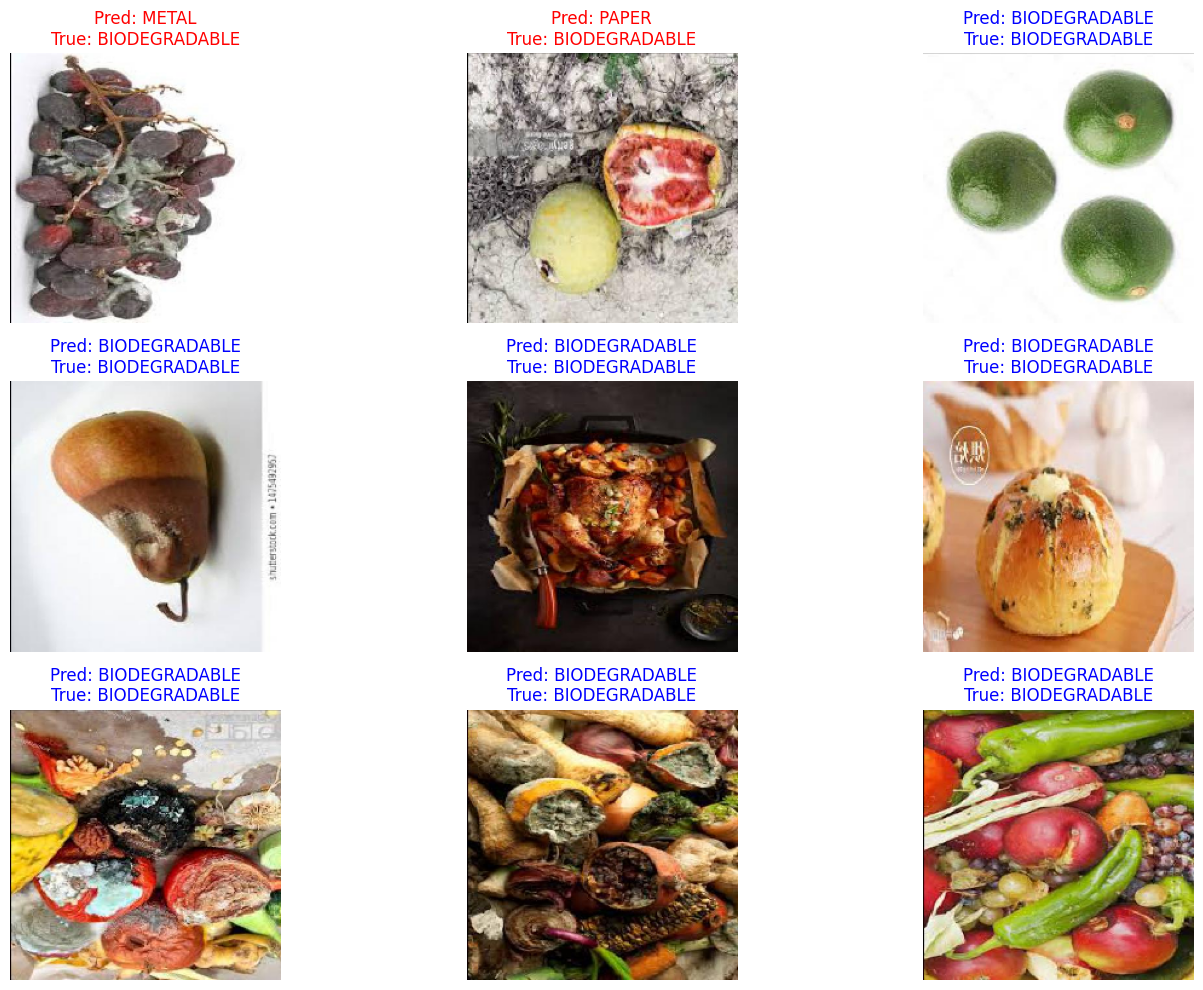

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Chuẩn bị generator cho tập test
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    '/content/datasets/garbage_classification/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 2. Đánh giá mô hình trên tập test
print('Đang đánh giá trên tập test...')
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy: {test_acc*100:.2f}%')

# 3. Dự đoán và hiển thị kết quả
class_labels = list(test_generator.class_indices.keys())
images, labels = next(test_generator)
preds = model.predict(images)

plt.figure(figsize=(15, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    pred_idx = np.argmax(preds[i])
    true_idx = np.argmax(labels[i])

    color = 'blue' if pred_idx == true_idx else 'red'
    plt.title(f'Pred: {class_labels[pred_idx]}\nTrue: {class_labels[true_idx]}', color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

Đang đánh giá mô hình sau khi chống Overfitting...
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.7222 - loss: 0.7750
Test Accuracy cuối cùng: 72.22%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


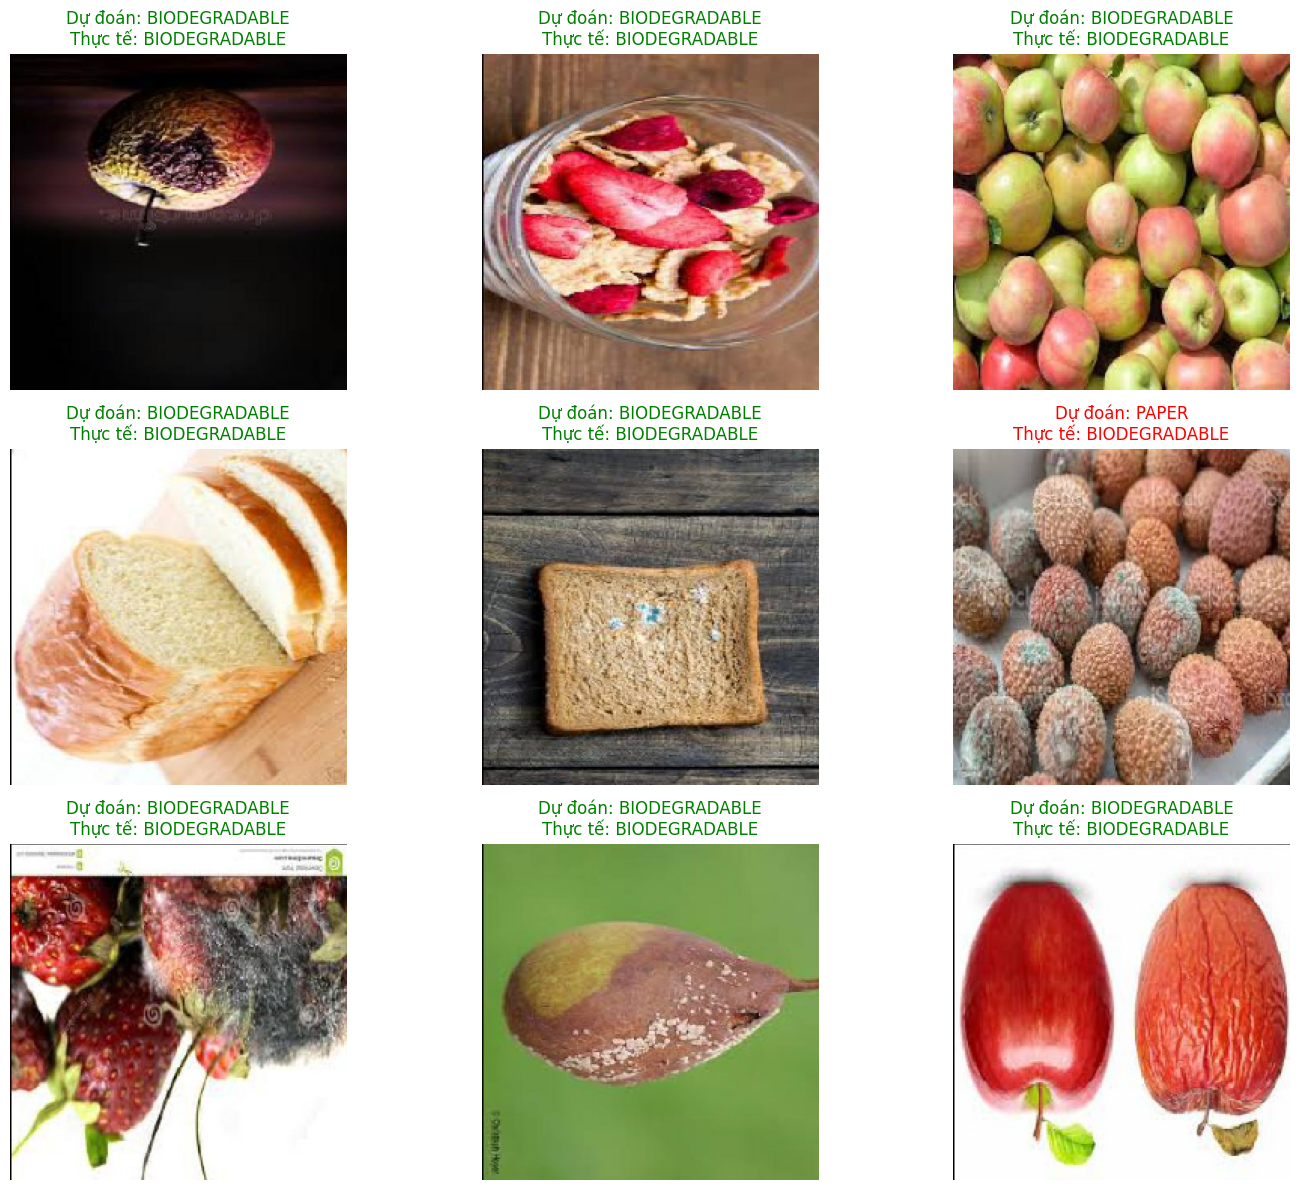

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Đánh giá trên tập test với mô hình đã cải thiện
print('Đang đánh giá mô hình sau khi chống Overfitting...')
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy cuối cùng: {test_acc*100:.2f}%')

# 2. Hiển thị dự đoán mẫu
class_labels = list(test_generator.class_indices.keys())
x_test, y_test = next(test_generator)
preds = model.predict(x_test)

plt.figure(figsize=(15, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i])

    pred_idx = np.argmax(preds[i])
    true_idx = np.argmax(y_test[i])

    color = 'green' if pred_idx == true_idx else 'red'
    plt.title(f'Dự đoán: {class_labels[pred_idx]}\nThực tế: {class_labels[true_idx]}', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Tự động dừng nếu val_loss không giảm sau 3 epoch
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 2. Tự động giảm learning rate nếu val_loss chững lại
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

print('Đang tiếp tục huấn luyện với Callbacks để tối ưu hóa...')

# Huấn luyện tiếp tục từ trạng thái hiện tại
history_fine = model.fit(
    train_generator,
    epochs=20, # Tăng số epoch tối đa, EarlyStopping sẽ tự dừng khi cần
    validation_data=validation_generator,
    callbacks=[early_stop, reduce_lr]
)

Đang tiếp tục huấn luyện với Callbacks để tối ưu hóa...
Epoch 1/20
583/583 ━━━━━━━━━━━━━━━━━━━━ 46s 79ms/step - accuracy: 0.9982 - loss: 0.0062 - val_accuracy: 0.6578 - val_loss: 3.2700 - learning_rate: 2.0000e-04
Epoch 2/20
583/583 ━━━━━━━━━━━━━━━━━━━━ 45s 77ms/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 0.6574 - val_loss: 3.3809 - learning_rate: 2.0000e-04
Epoch 3/20
583/583 ━━━━━━━━━━━━━━━━━━━━ 45s 77ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.6588 - val_loss: 3.4202 - learning_rate: 2.0000e-04
Epoch 4/20
583/583 ━━━━━━━━━━━━━━━━━━━━ 45s 77ms/step - accuracy: 0.9999 - loss: 8.3897e-04 - val_accuracy: 0.6616 - val_loss: 3.4471 - learning_rate: 4.0000e-05


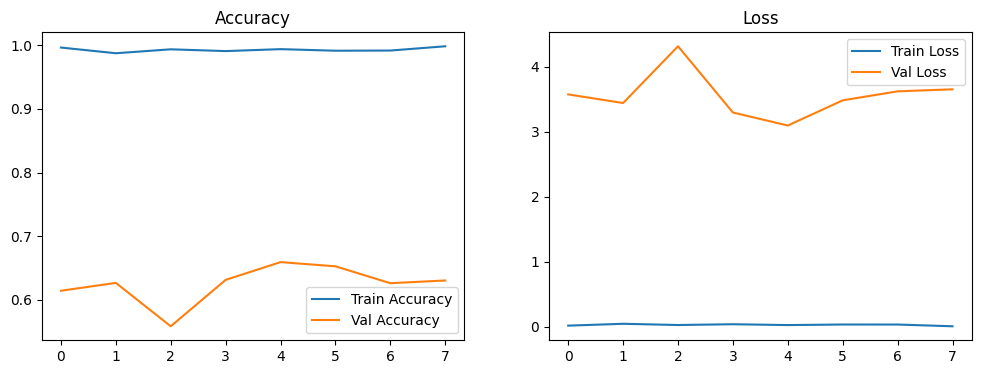

In [ ]:
import matplotlib.pyplot as plt

acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']
loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Tạo generator cho tập test
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    '/content/datasets/garbage_classification/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 2. Đánh giá trên tập test
print('Đang đánh giá mô hình trên tập test...')
loss, acc = model.evaluate(test_generator)
print(f'Test Accuracy: {acc*100:.2f}%')

# 3. Dự đoán và hiển thị kết quả mẫu
class_indices = train_generator.class_indices
labels = {v: k for k, v in class_indices.items()}

x_test, y_test = next(test_generator)
predictions = model.predict(x_test)

plt.figure(figsize=(15, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i])

    pred_label = labels[np.argmax(predictions[i])]
    true_label = labels[np.argmax(y_test[i])]

    color = 'green' if pred_label == true_label else 'red'
    plt.title(f'Dự đoán: {pred_label}\nThực tế: {true_label}', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil

def organize_garbage_dataset(base_path):
    categories = ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC']
    subsets = ['train', 'valid', 'test']

    for subset in subsets:
        subset_dir = os.path.join(base_path, subset)
        images_dir = os.path.join(subset_dir, 'images')

        if not os.path.exists(images_dir):
            print(f'Skipping {subset}: No images folder found at {images_dir}')
            continue

        for cat in categories:
            os.makedirs(os.path.join(subset_dir, cat), exist_ok=True)

        for filename in os.listdir(images_dir):
            for cat in categories:
                if filename.lower().startswith(cat.lower()):
                    shutil.move(os.path.join(images_dir, filename), os.path.join(subset_dir, cat, filename))
                    break
        print(f'Done organizing {subset} directory.')

organize_garbage_dataset('/content/datasets/garbage_classification')

Done organizing train directory.
Done organizing valid directory.
Done organizing test directory.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Now pointing to the subset root where category folders exist
train_generator = train_datagen.flow_from_directory(
    '/content/datasets/garbage_classification/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    '/content/datasets/garbage_classification/valid',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 18649 images belonging to 8 classes.
Found 2113 images belonging to 8 classes.
